# ResNet-18 Quantisation Sweep — Analysis

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import load_runs, flatten_runs

runs = load_runs('../runs', status='ok')
df   = pd.DataFrame(flatten_runs(runs))

df['backend']    = df['cfg.backend']
df['precision']  = df['cfg.model_precision']
df['input_bits'] = df['cfg.input_quant_bits'].fillna(0).astype(int)
df['top1']       = df['res.top1_acc']
df['top5']       = df['res.top5_acc']
df['lat_ms']     = df['res.infer_ms_avg']
df['tput']       = df['res.throughput_infer_sps']

print(f'{len(df)} runs loaded')

table = (
    df[['backend','precision','input_bits','top1','top5','lat_ms','tput']]
    .sort_values(['backend','precision','input_bits'])
    .reset_index(drop=True)
)

# Draw a thick top border on every row where precision changes
def border_on_precision_change(df):
    styles = [[''] * len(df.columns)] * len(df)
    styles = [list(row) for row in styles]
    for i in range(1, len(df)):
        if df.iloc[i]['precision'] != df.iloc[i-1]['precision']:
            styles[i] = ['border-top: 2px solid black'] * len(df.columns)
    return pd.DataFrame(styles, index=df.index, columns=df.columns)

table.style.apply(border_on_precision_change, axis=None)

17 runs loaded


,backend,precision,input_bits,top1,top5,lat_ms,tput
0,pytorch,fp16,1,1.200000,7.200000,2.827483,353.671490
1,pytorch,fp16,2,31.800000,55.200000,3.148344,317.627343
2,pytorch,fp16,4,76.600000,94.000000,3.065862,326.172538
3,pytorch,fp16,8,78.297872,94.255319,2.791566,358.221875
4,pytorch,fp32,1,1.200000,7.200000,2.774551,360.418698
5,pytorch,fp32,2,31.800000,55.000000,2.809399,355.948067
6,pytorch,fp32,4,76.800000,94.000000,3.171404,315.317800
7,pytorch,fp32,8,78.297872,94.255319,2.957925,338.074874
8,tensorrt,fp16,8,78.297872,94.255319,0.476711,2097.706954
9,tensorrt,fp32,8,78.297872,94.255319,0.940200,1063.603983


In [4]:
df_8b = df[df['input_bits'] == 8]

table = (
    df_8b[['backend','precision','top1','top5','lat_ms','tput']]
    .sort_values(['backend','precision',])
    .reset_index(drop=True)
)

df_8b

,run_id,status,error,total_eval_time_sec,_result_path,_run_dir,system.cuda_available,system.device,system.timestamp,system.torch,...,res.top5_acc,res.total_batches,res.total_samples,backend,precision,input_bits,top1,top5,lat_ms,tput
3,resnet18_pytorch_fp16_in8b_cuda_bs1,ok,None,5.811,../runs/resnet18_pytorch_fp16_in8b_cuda_bs1/re...,../runs/resnet18_pytorch_fp16_in8b_cuda_bs1,True,cuda,2026-03-05 21:16:54,2.10.0+cu128,...,95.9,1000,1000,pytorch,fp16,8,84.9,95.9,3.102972,322.271700
7,resnet18_pytorch_fp32_in8b_cuda_bs1,ok,None,5.919,../runs/resnet18_pytorch_fp32_in8b_cuda_bs1/re...,../runs/resnet18_pytorch_fp32_in8b_cuda_bs1,True,cuda,2026-03-05 21:15:52,2.10.0+cu128,...,95.9,1000,1000,pytorch,fp32,8,84.8,95.9,2.832111,353.093486
11,resnet18_tensorrt_fp16_in8b_cuda_bs1,ok,None,3.851,../runs/resnet18_tensorrt_fp16_in8b_cuda_bs1/r...,../runs/resnet18_tensorrt_fp16_in8b_cuda_bs1,True,cuda,2026-03-05 20:59:49,2.10.0+cu128,...,95.9,1000,1000,tensorrt,fp16,8,84.7,95.9,0.474607,2107.006559
15,resnet18_tensorrt_fp32_in8b_cuda_bs1,ok,None,4.146,../runs/resnet18_tensorrt_fp32_in8b_cuda_bs1/r...,../runs/resnet18_tensorrt_fp32_in8b_cuda_bs1,True,cuda,2026-03-05 20:59:45,2.10.0+cu128,...,95.9,1000,1000,tensorrt,fp32,8,84.8,95.9,0.933835,1070.853463
19,resnet18_tensorrt_fp8_in8b_cuda_bs1,ok,None,3.922,../runs/resnet18_tensorrt_fp8_in8b_cuda_bs1/re...,../runs/resnet18_tensorrt_fp8_in8b_cuda_bs1,True,cuda,2026-03-05 20:59:57,2.10.0+cu128,...,95.9,1000,1000,tensorrt,fp8,8,84.7,95.9,0.506197,1975.516616
23,resnet18_tensorrt_int4_in8b_cuda_bs1,ok,None,3.915,../runs/resnet18_tensorrt_int4_in8b_cuda_bs1/r...,../runs/resnet18_tensorrt_int4_in8b_cuda_bs1,True,cuda,2026-03-05 21:00:01,2.10.0+cu128,...,95.9,1000,1000,tensorrt,int4,8,84.7,95.9,0.483584,2067.894302
27,resnet18_tensorrt_int8_in8b_cuda_bs1,ok,None,4.072,../runs/resnet18_tensorrt_int8_in8b_cuda_bs1/r...,../runs/resnet18_tensorrt_int8_in8b_cuda_bs1,True,cuda,2026-03-05 20:59:53,2.10.0+cu128,...,96.0,1000,1000,tensorrt,int8,8,85.0,96.0,0.754126,1326.038237
31,resnet18_torchao_cpu_ptq_int8_in8b_cpu_bs1,ok,None,16.861,../runs/resnet18_torchao_cpu_ptq_int8_in8b_cpu...,../runs/resnet18_torchao_cpu_ptq_int8_in8b_cpu...,True,cpu,2026-03-05 21:04:33,2.10.0+cu128,...,95.9,1000,1000,torchao_cpu_ptq,int8,8,84.8,95.9,10.433682,95.843444


## Plot 1 — Top-1 Accuracy by Precision (grouped by backend, faceted by input_bits)

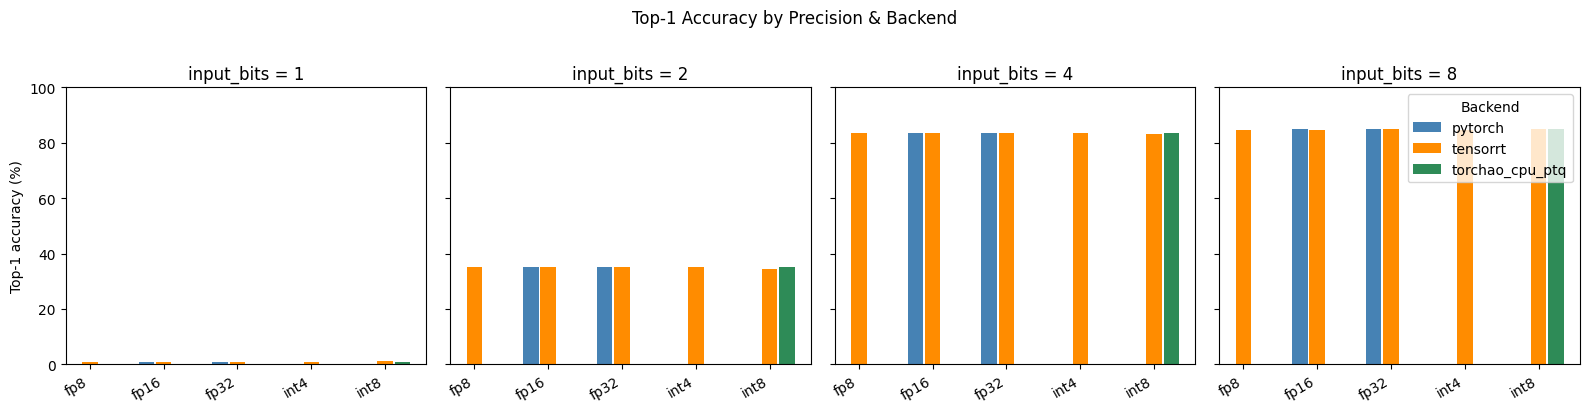

In [3]:
PRECISION_ORDER = ['fp8', 'fp16', 'fp32', 'int4', 'int8']
INPUT_BITS_LIST = sorted(df['input_bits'].unique())
BACKENDS        = sorted(df['backend'].unique())
COLORS          = ['steelblue', 'darkorange', 'seagreen']

n      = len(INPUT_BITS_LIST)
bar_w  = 0.7 / len(BACKENDS)
x      = np.arange(len(PRECISION_ORDER))

fig, axes = plt.subplots(1, n, figsize=(4*n, 4), sharey=True)
if n == 1: axes = [axes]

for ax, bits in zip(axes, INPUT_BITS_LIST):
    sub = df[df['input_bits'] == bits]
    for i, (backend, color) in enumerate(zip(BACKENDS, COLORS)):
        bdf = sub[sub['backend'] == backend].set_index('precision')
        ys  = [bdf.loc[p, 'top1'] if p in bdf.index else np.nan for p in PRECISION_ORDER]
        ax.bar(x + i*bar_w - (len(BACKENDS)-1)*bar_w/2, ys, width=bar_w*0.9,
               color=color, label=backend)
    ax.set_title(f'input_bits = {bits}')
    ax.set_xticks(x)
    ax.set_xticklabels(PRECISION_ORDER, rotation=30, ha='right')
    ax.set_ylim(0, 100)

axes[0].set_ylabel('Top-1 accuracy (%)')
axes[-1].legend(title='Backend')
fig.suptitle('Top-1 Accuracy by Precision & Backend', y=1.02)
plt.tight_layout()
plt.savefig('../runs/plot1_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2 — Accuracy vs Latency (scatter)

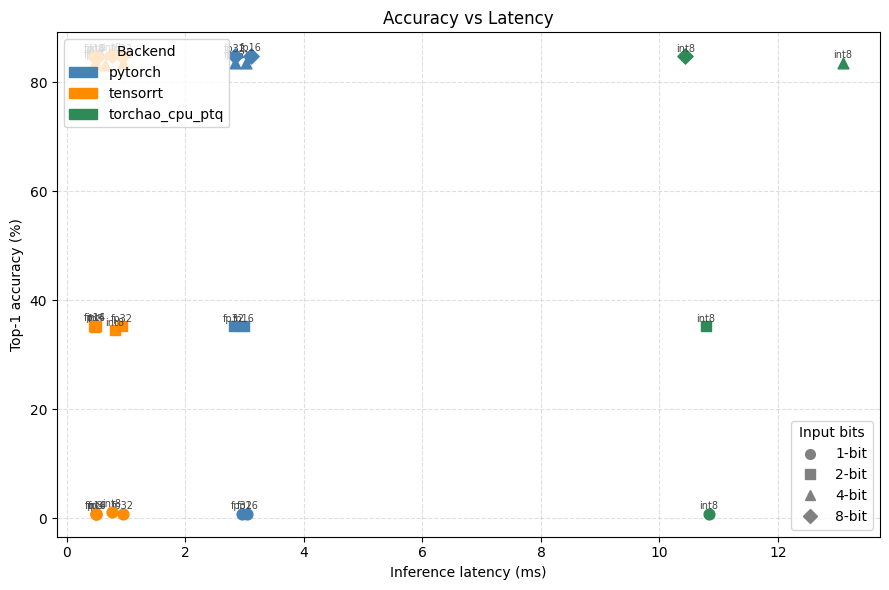

In [4]:
MARKERS = {1: 'o', 2: 's', 4: '^', 8: 'D'}

fig, ax = plt.subplots(figsize=(9, 6))

for (backend, bits), grp in df.groupby(['backend', 'input_bits']):
    color  = COLORS[BACKENDS.index(backend)]
    marker = MARKERS.get(bits, 'o')
    for _, row in grp.iterrows():
        ax.scatter(row['lat_ms'], row['top1'], color=color, marker=marker,
                   s=60, zorder=3)
        ax.text(row['lat_ms'], row['top1'] + 0.5, row['precision'],
                fontsize=7, ha='center', va='bottom', color='#444')

# Legends
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
color_leg = [mpatches.Patch(color=c, label=b) for b, c in zip(BACKENDS, COLORS)]
marker_leg = [Line2D([0],[0], marker=MARKERS.get(b,'o'), color='gray',
                      linestyle='None', markersize=7, label=f'{b}-bit') for b in sorted(MARKERS)]
l1 = ax.legend(handles=color_leg,  title='Backend',    loc='upper left')
ax.legend(handles=marker_leg, title='Input bits', loc='lower right')
ax.add_artist(l1)

ax.set_xlabel('Inference latency (ms)')
ax.set_ylabel('Top-1 accuracy (%)')
ax.set_title('Accuracy vs Latency')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../runs/plot2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 3 — Accuracy vs Input Bits

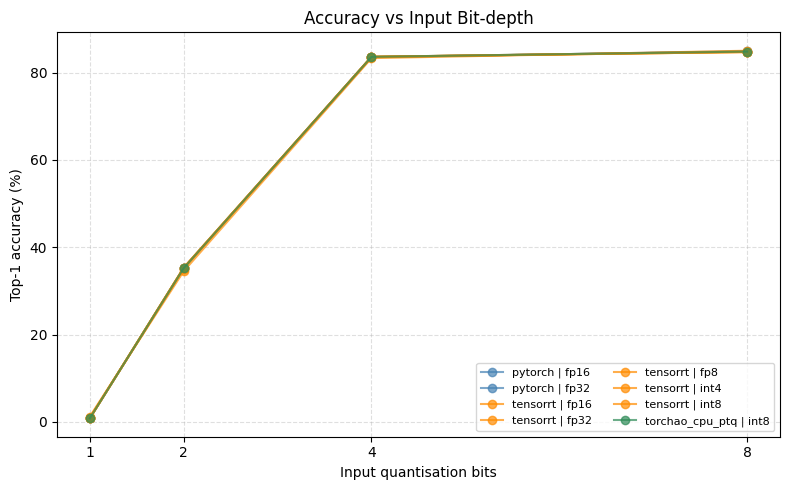

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

for (backend, prec), grp in df.groupby(['backend', 'precision']):
    color = COLORS[BACKENDS.index(backend)]
    grp   = grp.sort_values('input_bits')
    ax.plot(grp['input_bits'], grp['top1'], marker='o', color=color,
            alpha=0.7, linewidth=1.5, label=f'{backend} | {prec}')

ax.set_xlabel('Input quantisation bits')
ax.set_ylabel('Top-1 accuracy (%)')
ax.set_title('Accuracy vs Input Bit-depth')
ax.set_xticks(INPUT_BITS_LIST)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../runs/plot3_acc_vs_bits.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4 — Latency by Run

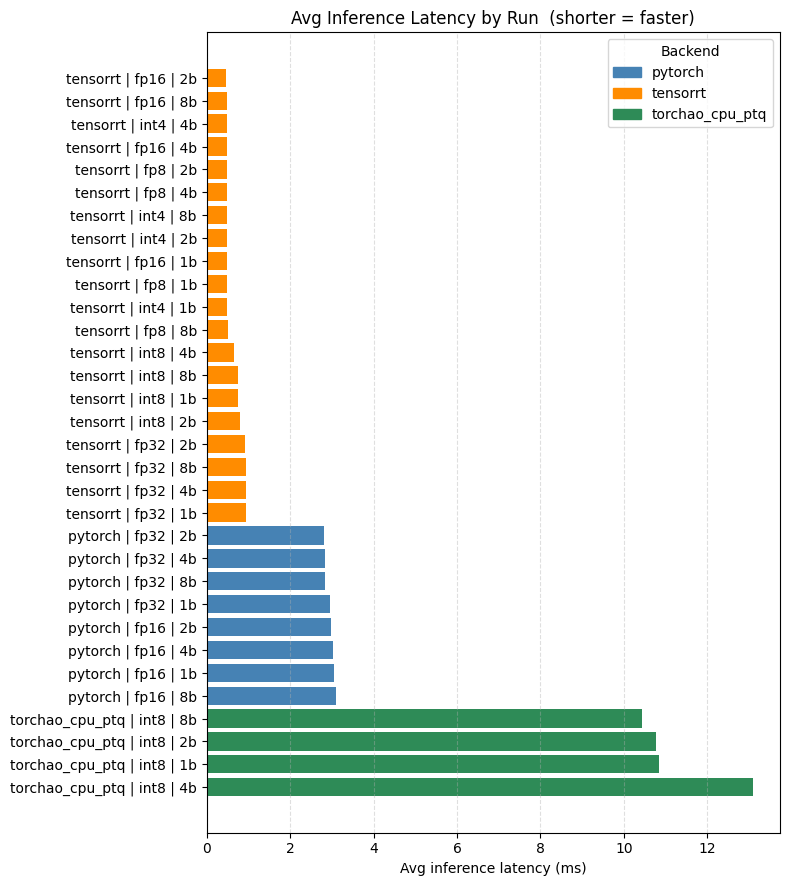

In [7]:
lat = (
    df.dropna(subset=['lat_ms'])
    .assign(label=lambda x: x['backend'] + ' | ' + x['precision'] + ' | ' + x['input_bits'].astype(str) + 'b')
    .sort_values('lat_ms', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, max(5, len(lat)*0.28)))

colors = [COLORS[BACKENDS.index(b)] for b in lat['backend']]
ax.barh(lat['label'], lat['lat_ms'], color=colors)

ax.set_xlabel('Avg inference latency (ms)')
ax.set_title('Avg Inference Latency by Run  (shorter = faster)')
ax.grid(axis='x', linestyle='--', alpha=0.4)

legend_h = [mpatches.Patch(color=c, label=b) for b, c in zip(BACKENDS, COLORS)]
ax.legend(handles=legend_h, title='Backend')
plt.tight_layout()
plt.savefig('../runs/plot4_latency.png', dpi=150, bbox_inches='tight')
plt.show()